# Day9: 실습을 통해 익히는 생성형AI

## 학습 내용
1. LangGraph reducer
2. RAG agent 구현하기
3. Streamlit을 이용한 챗봇 인터페이스


## 참고자료
  - LangChain docs: https://docs.langchain.com/
  - 인프런: AI 에이전트로 구현하는 RAG 시스템(판다스 스튜디오)

In [ ]:
!pip install -qU langchain langchain-openai langchain-community langchain-core langgraph wikipedia langchain_chroma langchain_ollama
# !pip install langchain-google-genai

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, json, re
from IPython.display import Image

import langchain, langchain_core, langchain_community, wikipedia

from langchain_openai import ChatOpenAI
# from langchain_google_genai import ChatGoogleGenerativeAI

import warnings
warnings.filterwarnings("ignore")

print("langchain version = ", langchain.__version__)
print("langchain core version = ", langchain_core.__version__)
print("langchain community version = ", langchain_community.__version__)
print("langchain community version = ", langchain_community.__version__)
print("wikipedia version = ", wikipedia.__version__)


langchain version =  1.0.5
langchain core version =  1.0.5
langchain community version =  0.4.1
langchain community version =  0.4.1
wikipedia version =  (1, 4, 0)


## API load

In [ ]:
# Set the API key
# os.environ['OPENAI_API_KEY'] = api_key
# os.environ['GOOGLE_API_KEY'] = api_key

from dotenv import load_dotenv
load_dotenv("/content/drive/MyDrive/LangChain_API/.env")

# os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

True

## LangGraph reducer
- 그래프의 상태(State) 업데이트 로직을 정의하는 핵심 메커니즘
- 각 노드(Node)가 실행된 후 반환하는 변경 사항들을 기존 상태에 어떻게 병합할지 결정하는 함수

### Reducer 사용 예제 1

In [ ]:
## 기본 Reducer 사용

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from operator import add

# 1. 상태 정의 (State Definition)
class QuizState(TypedDict):
    # 'total_score' 키에 Reducer를 연결합니다.
    # 이전 상태의 'total_score'와 현재 노드의 출력을 'add' 연산으로 합산합니다.
    total_score: Annotated[int, add]

# 2. 노드 함수 정의 (Node Functions)
def start_test(state):
    print("-> 테스트 시작: 10점 획득")
    # 'total_score'의 초기값 또는 첫 번째 합산 값이 됩니다.
    return {"total_score": 10}

def answer_q1(state):
    print("-> Q1 정답: 5점 추가")
    return {"total_score": 5}

def answer_q2(state):
    print("-> Q2 정답: 7점 추가")
    return {"total_score": 7}


-> 테스트 시작: 10점 획득
-> Q1 정답: 5점 추가
-> Q2 정답: 7점 추가

--- 결과 ---
최종 상태: {'total_score': 7}
최종 총점 (total_score): 7


In [ ]:
# 3. 그래프 구성 및 실행
workflow = StateGraph(QuizState)

# 노드 추가
workflow.add_node("start", start_test)
workflow.add_node("q1", answer_q1)
workflow.add_node("q2", answer_q2)

# 흐름 정의 (순차적)
workflow.add_edge(START, "start")
workflow.add_edge("start", "q1")
workflow.add_edge("q1", "q2")
workflow.add_edge("q2", END)



In [ ]:
# 컴파일
app = workflow.compile()

# 실행
final_state = app.invoke({})

print("\n--- 결과 ---")
print(f"최종 상태: {final_state}")
print(f"최종 총점 (total_score): {final_state['total_score']}")

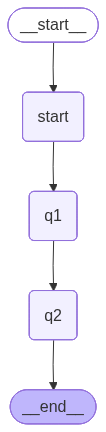

In [ ]:
Image(app.get_graph().draw_mermaid_png())

In [ ]:
## Add Reducer 사용

from langgraph.graph import StateGraph, START, END
from operator import add
from typing import TypedDict, Annotated

# 1. 상태 정의 (State Definition)
class QuizState(TypedDict):
    # 'total_score' 키에 Reducer를 연결합니다.
    # 이전 상태의 'total_score'와 현재 노드의 출력을 'add' 연산으로 합산합니다.
    total_score: Annotated[int, add]

# 2. 노드 함수 정의 (Node Functions)
def start_test(state):
    print("-> 테스트 시작: 10점 획득")
    # 'total_score'의 초기값 또는 첫 번째 합산 값이 됩니다.
    return {"total_score": 10}

def answer_q1(state):
    print("-> Q1 정답: 5점 추가")
    return {"total_score": 5}

def answer_q2(state):
    print("-> Q2 정답: 7점 추가")
    return {"total_score": 7}


-> 테스트 시작: 10점 획득
-> Q1 정답: 5점 추가
-> Q2 정답: 7점 추가

--- 결과 ---
최종 상태: {'total_score': 22}


In [ ]:
# 3. 그래프 구성 및 실행
workflow = StateGraph(QuizState)

# 노드 추가
workflow.add_node("start", start_test)
workflow.add_node("q1", answer_q1)
workflow.add_node("q2", answer_q2)

# 흐름 정의 (순차적)
workflow.add_edge(START, "start")
workflow.add_edge("start", "q1")
workflow.add_edge("q1", "q2")
workflow.add_edge("q2", END)



In [ ]:
# 컴파일
app = workflow.compile()

# 실행
final_state = app.invoke({})

print("\n--- 결과 ---")
print(f"최종 상태: {final_state}")

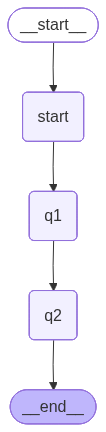

In [ ]:
Image(app.get_graph().draw_mermaid_png())

### Reducer 사용 예제 2

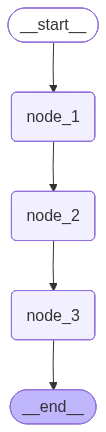

In [ ]:
## 기본 Reducer 사용

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image

# 상태 정의
class DocumentState(TypedDict):
    query: str
    documents: list[str]

# Node 1: query 업데이트
def node_1(state: DocumentState) -> DocumentState:
    print("---Node 1 (query update)---")
    query = state["query"] # 실제 변경사항은 없으나 업데이트했다고 가정
    return {"query": query}

# Node 2: 검색된 문서 추가
def node_2(state: DocumentState) -> DocumentState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: DocumentState) -> DocumentState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}


# 그래프 빌드
builder = StateGraph(DocumentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
# 초기 상태
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요."}

# 그래프 실행
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc2.pdf', 'doc4.pdf', 'doc5.pdf']}


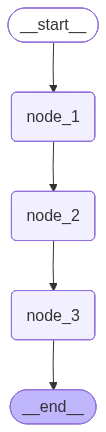

In [ ]:
from operator import add
from typing import Annotated, TypedDict

class ReducerState(TypedDict):
    query: str
    documents: Annotated[list[str], add]

# Node 1: query 업데이트
def node_1(state: ReducerState) -> ReducerState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가
def node_2(state: ReducerState) -> ReducerState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: ReducerState) -> ReducerState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프 빌드
builder = StateGraph(ReducerState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
# 초기 상태
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요."}

# 그래프 실행
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc1.pdf', 'doc2.pdf', 'doc3.pdf', 'doc2.pdf', 'doc4.pdf', 'doc5.pdf']}


### Custom reducer 사용하기

#### Custom reducer 예제1 :  list 중복 제거

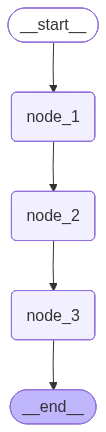

In [ ]:
from typing import TypedDict, Annotated

# Custom reducer: 중복된 문서를 제거하며 리스트 병합
def reduce_unique_documents(left: list[str], right: list[str]) -> list:
    """Combine two lists of documents, removing duplicates."""
    # 중복 제거: set을 사용하여 중복된 문서를 제거하고 다시 list로 변환
    return list(set(left + right))

# 상태 정의 (documents 필드 포함)
class CustomReducerState(TypedDict):
    query: str
    documents: Annotated[list[str], reduce_unique_documents]  # Custom Reducer 적용


# Node 1: query 업데이트
def node_1(state: CustomReducerState) -> CustomReducerState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가
def node_2(state: CustomReducerState) -> CustomReducerState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: CustomReducerState) -> CustomReducerState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프 빌드
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
# 초기 상태
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요.", "documents": []}

# 그래프 실행
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc2.pdf', 'doc3.pdf', 'doc1.pdf', 'doc5.pdf', 'doc4.pdf']}


#### Custom reducer 예제2 :  Max값 반환

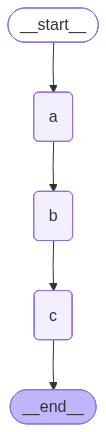

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
# import operator # operator.add 등 다른 리듀서와 비교할 수 있도록 임포트

# 1. 커스텀 리듀서 함수 정의
def find_max(current_value: int, new_value: int) -> int:
    """두 값 중 더 큰 값을 반환하는 커스텀 리듀서."""
    return max(current_value, new_value)

# 2. 상태 정의
class MaxScoreState(TypedDict):
    # 커스텀 함수 find_max를 리듀서로 연결합니다.
    high_score: Annotated[int, find_max]

# 3. 노드 함수 정의
def step_a(state: MaxScoreState):
    print("initial high_score = ", state["high_score"])
    print("-> Step A: 85점 입력")
    return {"high_score": 85}

def step_b(state: MaxScoreState):
    print("-> Step B: 92점 입력 (현재 최고: 85점)")
    return {"high_score": 92}

def step_c(state: MaxScoreState):
    print("-> Step C: 78점 입력 (현재 최고: 92점)")
    return {"high_score": 78}


# 4. 그래프 구성 및 실행
workflow = StateGraph(MaxScoreState)
workflow.add_node("a", step_a)
workflow.add_node("b", step_b)
workflow.add_node("c", step_c)

workflow.add_edge(START, "a")
workflow.add_edge("a", "b")
workflow.add_edge("b", "c")
workflow.add_edge("c", END)

app = workflow.compile()

# 그래프 시각화
Image(app.get_graph().draw_mermaid_png())

In [ ]:

# 실행: int의 기본값인 0으로 시작
final_state = app.invoke({})

print("\n--- 결과 ---")
print(f"최종 상태: {final_state}")
print(f"최종 최고 점수 (high_score): {final_state['high_score']}")

initial high_score =  0
-> Step A: 85점 입력
-> Step B: 92점 입력 (현재 최고: 85점)
-> Step C: 78점 입력 (현재 최고: 92점)

--- 결과 ---
최종 상태: {'high_score': 92}
최종 최고 점수 (high_score): 92


## Message Graph
- LangGraph 프레임워크 내에서 대화형 AI 에이전트의 복잡한 워크플로우와 상태를 관리하는 핵심 개념
- 기본 LangChain의 순차적 체인 구조를 넘어, 반복, 조건부 분기, 다중 에이전트 협업 등을 지원하는 데 사용

### Message Graph 예제 1

In [ ]:
from langgraph.graph import StateGraph, START, END, add_messages
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

# --- 1. GraphState 정의: add_messages를 사용 ---
class SimpleState(TypedDict):
    """메시지 누적을 위한 상태 정의"""
    # add_messages가 메시지를 리스트에 계속 추가(누적)합니다.
    messages: Annotated[list[AnyMessage], add_messages] # AnyMessage 는 모든 Message 타입 대응

# --- 2. 단일 처리 노드 정의 ---
def process_message_node(state: SimpleState) -> SimpleState:
    """
    상태를 받아 마지막 메시지를 처리하고, 새로운 응답 메시지를 반환합니다.
    """
    print("--- 노드 실행: 메시지 처리 중 ---")

    # 1. 상태에서 메시지 기록 확인 (누적되었는지 확인)
    history = state["messages"]
    last_user_message = history[-1].content

    print(f"   -> 현재 기록된 메시지 수: {len(history)}")
    print(f"   -> 받은 메시지 내용: '{last_user_message}'")

    # 2. 새로운 AIMessage 생성
    ai_response = f"응답: '{last_user_message}'에 대한 처리가 완료되었습니다."

    # 3. **새로운 메시지**만 포함하는 딕셔너리를 반환
    # add_messages가 이 메시지를 기존 history에 추가합니다.
    new_messages = [AIMessage(content=ai_response)] # LLM은 AI 메세지 타입으로 전달

    return {"messages": new_messages}

In [ ]:
# --- 3. 그래프 구축 및 실행 ---
builder = StateGraph(SimpleState)

# 단 하나의 노드만 추가
builder.add_node("processor", process_message_node)

# 시작 지점과 종료 지점을 같게 설정 (한 번 실행 후 끝남)
builder.add_edge(START, "processor")
builder.add_edge("processor", END)

app = builder.compile()

In [ ]:
# ---
## 실행 1: 첫 번째 호출
print("="*40)
print(" 실행 1: 첫 번째 메시지")
print("="*40)

# 1. invoke 입력: 초기 HumanMessage를 전달
initial_input = {"messages": [HumanMessage(content="Hello, world!")]}
final_state_1 = app.invoke(initial_input)

print("\n--- 실행 1 최종 상태 ---")
for i, msg in enumerate(final_state_1["messages"]):
    print(f"[{i+1}] {msg.__class__.__name__}: {msg.content}")


### Message Graph 예제 2

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 1. 상태 정의 (State Definition)
# BaseMessage: LangChain 메시지 객체들의 최상위 부모 클래스입니다. (HumanMessage, AIMessage, ToolMessage 등이 모두 이를 상속받습니다.)
class ChatState(TypedDict):
    # 'messages' 키는 BaseMessage의 리스트를 저장하며,
    # add_messages 리듀서를 사용하여 새로운 메시지를 리스트 끝에 추가합니다.
    messages: Annotated[list[BaseMessage], add_messages]

# 2. 노드 함수 정의 (Node Functions)

def user_input(state: ChatState):
    """사용자 메시지를 상태에 추가합니다."""
    # 노드는 반드시 BaseMessage의 리스트를 반환해야 합니다.
    print("initial = ", state["messages"])
    print("-> 사용자 입력 (HumanMessage) 생성")

    return {"messages": state["messages"]}

def agent_response(state: ChatState):
    """직전 메시지를 기반으로 에이전트의 답변을 생성합니다."""
    # state["messages"]는 현재까지의 전체 대화 기록입니다.
    last_message = state["messages"][-1].content

    # 챗봇 응답 로직
    if "계절" in last_message:
        response_content = "저는 낚엽이 떨어지는 가을을 가장 좋아합니다."
    elif "음식" in last_message:
        response_content = "저는 볶음밥을 가장 좋아합니다."
    else:
        response_content = "죄송해요, 다시 말씀해 주시겠어요?"

    print("-> 에이전트 응답 (AIMessage) 생성")
    agent_msg = AIMessage(content=response_content)
    # add_messages 리듀서는 메시지 객체를 리스트 형태로 받습니다.
    return {"messages": [agent_msg]}


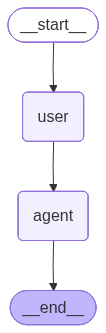

In [ ]:
# 3. 그래프 구성 및 실행
workflow = StateGraph(ChatState)

# 노드 추가
workflow.add_node("user", user_input)
workflow.add_node("agent", agent_response)

# 흐름 정의
workflow.add_edge(START, "user")
workflow.add_edge("user", "agent")
workflow.add_edge("agent", END)

# 컴파일
app = workflow.compile()

# 그래프 시각화
Image(app.get_graph().draw_mermaid_png())

In [ ]:
# 실행
# user_msg = HumanMessage(content="가장 좋아하는 계절은 무엇인가요?")
user_msg = HumanMessage(content="가장 좋아하는 음식은 무엇인가요?")

final_state = app.invoke({"messages": user_msg})

print("\n--- 결과 ---")
print(f"최종 메시지 수: {len(final_state['messages'])}")
for idx, msg in enumerate(final_state['messages']):
    print(f"[{idx+1}] Type: {type(msg).__name__}, Content: {msg.content}")

initial =  [HumanMessage(content='가장 좋아하는 음식은 무엇인가요?', additional_kwargs={}, response_metadata={}, id='64ae0b5e-a066-42cd-b741-d9864748f88a')]
-> 사용자 입력 (HumanMessage) 생성
-> 에이전트 응답 (AIMessage) 생성

--- 결과 ---
최종 메시지 수: 2
[1] Type: HumanMessage, Content: 가장 좋아하는 음식은 무엇인가요?
[2] Type: AIMessage, Content: 저는 볶음밥을 가장 좋아합니다.


### Message Graph 예제 3 : LLM 호출

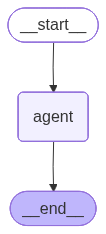

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, AnyMessage
from langchain_openai import ChatOpenAI  # OpenAI 모델 연결용


# 1. ChatGPT 모델 준비
llm = ChatOpenAI(model="gpt-4o-mini")

# 2. 상태 정의 (State Definition)
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 3. 노드 함수 정의 (Node Functions)

def agent_response(state: ChatState):
    """ChatGPT API를 호출하여 응답 생성"""
    print("-> ChatGPT 호출 중...")

    # LangChain의 ChatOpenAI는 대화 맥락 전체를 인식
    response = llm.invoke(state["messages"])  # 전체 메시지 전달

    # 응답은 BaseMessage (AIMessage) 타입으로 자동 변환됨
    print("-> ChatGPT 응답 생성 완료")
    return {"messages": [response]}

# 4. 그래프 구성
workflow = StateGraph(ChatState)

workflow.add_node("agent", agent_response)

workflow.add_edge(START, "agent")
workflow.add_edge("agent", END)

# 5. 그래프 컴파일
runnable = workflow.compile()

# 그래프 시각화
Image(runnable.get_graph().draw_mermaid_png())

In [ ]:
result = runnable.invoke({"messages": ["가장 좋아하는 과일은 무엇인가요?"]})
print("\n=== 최종 응답 ===")
print("\n=== 최종 응답 ===")
print(f'{type(result["messages"][0]).__name__}: ', result["messages"][0].content)
print(f'{type(result["messages"][1]).__name__}: ', result["messages"][1].content)

-> ChatGPT 호출 중...
-> ChatGPT 응답 생성 완료

=== 최종 응답 ===

=== 최종 응답 ===
HumanMessage:  가장 좋아하는 과일은 무엇인가요?
AIMessage:  제가 감정을 느끼거나 개인적인 취향이 없지만, 많은 사람들이 사과, 바나나, 딸기, 망고 등을 좋아한다고 알려져 있습니다. 여러분은 어떤 과일을 가장 좋아하시나요?


## MemorySaver
1. 상태의 일시성 문제:
   - 기본적으로 그래프 실행 시 상태는 일시적 (stateless)
   - 그래프를 재실행하는 경우 상태가 초기화되는 문제가 있음
   - 따라서, 중단이 있는 다중 턴 대화가 어려움

2. MemorySaver 기능:
   - 가장 쉽게 사용할 수 있는 체크포인터 (각 단계 후 그래프 상태를 자동으로 저장)
   - 그래프 상태를 위한 인메모리 키-값 저장소
   - 지속성(persistence) 있는 메모리 기능을 제공하여 그래프 객체가 체크포인터부터 이어서 실행 가능

3. 메모리의 필요성:
   - 대화의 연속성: 여러 턴에 걸친 대화를 유지
   - 중단 허용: 대화 중 중단이 있어도 이전 상태를 복원
   - 유연한 상태 관리: 다양한 대화 스레드를 독립적으로 관리

### MemorySaver 예제 1

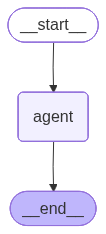

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver  # 메모리 세이버
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_openai import ChatOpenAI
from IPython.display import Image

# 1. LLM 준비
llm = ChatOpenAI(model="gpt-4o-mini")

# 2. 상태 정의 (State Definition)
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 3. 노드 함수 정의
def agent_response(state: ChatState):
    """ChatGPT API를 호출하여 응답 생성"""
    print("-> ChatGPT 호출 중...")

    # LangChain의 ChatOpenAI는 대화 맥락 전체를 인식
    response = llm.invoke(state["messages"])  # 전체 메시지 전달

    print("-> ChatGPT 응답 생성 완료")
    return {"messages": [response]}

# 4. 그래프 구성
builder = StateGraph(ChatState)
builder.add_node("agent", agent_response)

builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# 5. MemorySaver 체크포인터 지정
memory = MemorySaver()

# 6. 그래프 컴파일 (checkpointer 포함)
graph_memory = builder.compile(checkpointer=memory)

# 7. 그래프 시각화
Image(graph_memory.get_graph().draw_mermaid_png())


In [ ]:
# 8. 대화 실행
print("MemorySaver Chat 시작 ('quit' 입력 시 종료)\n")

config = {"configurable": {"thread_id": "user1"}}  # 스레드 ID별로 상태 분리 가능

while True:
    user_input = input("You: ")
    if user_input.lower() in {"quit", "exit"}:
        print("대화를 종료합니다.")
        break

    # MemorySaver를 사용하면 thread_id에 따라 이전 상태 자동 이어짐
    result = graph_memory.invoke({"messages": [HumanMessage(content=user_input)]}, config)

    # 결과 출력
    ai_messages = [m for m in result["messages"] if isinstance(m, AIMessage)]
    if ai_messages:
        print("AI:", ai_messages[-1].content)


MemorySaver Chat 시작 ('quit' 입력 시 종료)

You: 안녕하세요
-> ChatGPT 호출 중...
-> ChatGPT 응답 생성 완료
AI: 안녕하세요! 어떻게 도와드릴까요?
You: 가을입니다
-> ChatGPT 호출 중...
-> ChatGPT 응답 생성 완료
AI: 가을은 정말 아름다운 계절이죠! 나뭇잎이 색깔이 변하고, 선선한 바람이 불어서 산책하기 좋은 날씨가 많아지는데요. 가을의 어떤 점이 가장 좋으신가요? 단풍놀이, 수확, 아니면 따뜻한 음료를 즐기는 것 등 다양한 즐거움이 있겠네요!
You: 커피가 좋아요
-> ChatGPT 호출 중...
-> ChatGPT 응답 생성 완료
AI: 커피를 좋아하시군요! 가을에 따뜻한 커피 한 잔은 정말 좋죠. 특히, 캐러멜 마끼아또나 펌킨 스파이스 라떼 같은 계절 한정 음료는 가을의 분위기와 잘 어울리기도 하고요. 좋아하는 커피 종류나 카페가 있으신가요?
You: 제가 좋아 하는 것은?
-> ChatGPT 호출 중...
-> ChatGPT 응답 생성 완료
AI: 죄송하지만, 저는 귀하에 대한 정보를 알 수 없기 때문에 귀하가 좋아하는 특정 커피 종류를 말씀드릴 수는 없어요. 그러나 커피에 대해 여러 가지 대화를 나눌 수 있습니다! 혹시 어떤 종류의 커피를 즐기시나요? 에스프레소, 아메리카노, 라떼, 또는 다른 무엇이든지요?
You: quit
대화를 종료합니다.


### MemorySaver 예제 2

In [ ]:
from operator import add
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 1. 상태 정의 (TypedDict 사용)
# 'messages'를 정의하고, 'add' 연산자를 사용하여 새 메시지를 기존 목록에 추가합니다.
class SimpleState(TypedDict):
    """대화 기록을 저장하는 간단한 상태"""
    messages: Annotated[list[str], add]

# 2. 노드(Node) 함수 정의
def count_and_respond(state: SimpleState):
    """
    현재 스레드의 대화 기록 개수를 세어 응답을 생성합니다.
    (입력 메시지 자체도 포함되므로 -1을 합니다.)
    """
    # 현재까지 누적된 메시지 개수 (입력 메시지 포함)
    total_messages = len(state["messages"])
    # 이전 대화 횟수 (현재 입력 메시지 제외)
    past_interactions = total_messages - 1
    last_msg = state["messages"][-1]

    # 스레드 ID에 따라 고유한 상태가 유지됩니다.
    response = f"시스템 응답: '{last_msg}'을(를) 받았고, 이전 대화 기록은 {past_interactions}건 입니다."

    return {"messages": [response]}

# 3. 그래프 구축 및 컴파일
builder = StateGraph(SimpleState)
builder.add_node("agent", count_and_respond)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# MemorySaver를 checkpointer로 사용하여 스레드 상태를 저장합니다.
app = builder.compile(checkpointer=MemorySaver())

# 4. 두 개의 독립적인 스레드 시뮬레이션
USER1_ID = "thread_a"
USER2_ID = "thread_b"
config_a = {"configurable": {"thread_id": USER1_ID}}
config_b = {"configurable": {"thread_id": USER2_ID}}

print("---  스레드 A 상호작용 ---")
# 1차 호출 (입력 1 + 출력 1 = 총 2 메시지)
response_a = app.invoke({"messages": ["A가 첫 메시지를 보냅니다."]}, config=config_a)
# 2차 호출 (입력 1 + 출력 1이 추가되어 총 4 메시지)
response_a = app.invoke({"messages": ["A가 두 번째 메시지를 보냅니다."]}, config=config_a)

print(f"스레드 A의 최종 응답: {response_a['messages'][-1]}")
# 상태를 직접 확인: 입력 2 + 출력 2 = 4개
final_state_a = app.get_state(config_a).values
print(f" 스레드 A 최종 메시지 개수: {len(final_state_a['messages'])}\n")
print("-" * 30)

print("---  스레드 B 상호작용 (A와 완전히 독립적) ---")
# 1차 호출 (입력 1 + 출력 1 = 총 2 메시지)
response_b = app.invoke({"messages": ["안녕! 나는 B야."]}, config=config_b)

print(f" 스레드 B의 최종 응답: {response_b['messages'][-1]}")
# 상태를 직접 확인: 입력 1 + 출력 1 = 2개
final_state_b = app.get_state(config_b).values
print(f" 스레드 B 최종 메시지 개수: {len(final_state_b['messages'])}\n")
print("-" * 30)

---  스레드 A 상호작용 ---
스레드 A의 최종 응답: 시스템 응답: 'A가 두 번째 메시지를 보냅니다.'을(를) 받았고, 이전 대화 기록은 2건 입니다.
 스레드 A 최종 메시지 개수: 4

------------------------------
---  스레드 B 상호작용 (A와 완전히 독립적) ---
 스레드 B의 최종 응답: 시스템 응답: '안녕! 나는 B야.'을(를) 받았고, 이전 대화 기록은 0건 입니다.
 스레드 B 최종 메시지 개수: 2

------------------------------


In [ ]:
from rich import print as pp
from rich.console import Console
console = Console()

pp(app.get_state(config_a).values)
console.rule()
pp(app.get_state(config_b).values)


{
    'messages': [
        'A가 첫 메시지를 보냅니다.',
        "시스템 응답: 'A가 첫 메시지를 보냅니다.'을(를) 받았고, 이전 대화 기록은 0건 입니다.",
        'A가 두 번째 메시지를 보냅니다.',
        "시스템 응답: 'A가 두 번째 메시지를 보냅니다.'을(를) 받았고, 이전 대화 기록은 2건 입니다."
    ]
}

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

{'messages': ['안녕! 나는 B야.', "시스템 응답: '안녕! 나는 B야.'을(를) 받았고, 이전 대화 기록은 0건 입니다."]}

## Streamlit 을 이용한 챗봇 구현

In [ ]:
import streamlit as st
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_openai import ChatOpenAI
import os

# 1. LLM 모델 준비
llm = ChatOpenAI(model="gpt-4o-mini")

# 2. 상태 정의
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 3. 노드 함수 정의
def agent_response(state: ChatState):
    # LangChain 메시지 목록을 LLM에 전달
    response = llm.invoke(state["messages"])
    # LLM 응답을 메시지 목록에 추가
    return {"messages": [response]}

# 4. 그래프 구성
builder = StateGraph(ChatState)
builder.add_node("agent", agent_response)

builder.add_edge(START, "agent")
builder.add_edge("agent", END)

# 5. MemorySaver 적용
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# Streamlit UI
st.set_page_config(page_title="LangGraph MemorySaver Chatbot", page_icon="💬")
st.title("💬 LangGraph + MemorySaver Chatbot")

# 사용자 식별용 thread_id
# thread_id가 변경되면 LangGraph가 새 세션(새 기록)을 시작합니다.
thread_id = st.text_input(" Thread ID (사용자 세션 구분용)", "user1")
config = {"configurable": {"thread_id": thread_id}}

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# 사용자 입력 처리
user_input = st.chat_input("메시지를 입력하세요...")

if user_input:
    # 1. 사용자 메시지 출력 (반복 방지)
    with st.chat_message("user"):
        st.markdown(user_input)
    st.session_state.messages.append({"role": "user", "content": user_input})

    # 2. LangGraph 호출
    input_state = {"messages": [HumanMessage(content=user_input)]}
    # invoke 시 MemorySaver가 자동으로 기존 기록을 불러와 새 기록을 저장합니다.
    result = graph_memory.invoke(input_state, config)
    ai_response = result["messages"][-1].content

    # 3. AI 응답 출력
    with st.chat_message("assistant"):
        st.markdown(ai_response)
    st.session_state.messages.append({"role": "assistant", "content": ai_response})


Writing app.py
